In [134]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [135]:
csv_file_path = '/content/drive/MyDrive/datasets/nasdaq_multivariate.csv'

import pandas as pd
df = pd.read_csv(csv_file_path)

In [136]:
import numpy as np

TRAIN_RATIO = 0.7
VAL_RATIO = 0.1
TEST_RATIO = 0.1

df["Regime"] = (df["Close"] > df["Close"].rolling(60).mean()).astype(int)
df["VIX_percentile"] = df["VIX"].rolling(252).rank(pct=True)

# 20日远期收益（单点目标，无滚动窗口重叠）
df["Forward_20d"] = df["Close"].shift(-20) / df["Close"] - 1
df["target"] = (df["Forward_20d"] > df["Forward_20d"].median()).astype(int)

# ── 特征工程 ──────────────────────────────────────────
df["Momentum_20d"]  = df["Close"] / df["Close"].shift(20) - 1
df["Momentum_60d"]  = df["Close"] / df["Close"].shift(60) - 1
df["Momentum_252d"] = df["Close"] / df["Close"].shift(252) - 1

df["Volatility_20d"] = df["Return"].rolling(20).std()
df["ATR_14"] = (df["High"] - df["Low"]).rolling(14).mean() / df["Close"]

df["Yield_slope"]   = df["TNX"] - df["FedRate"]
df["Dist_52w_high"] = df["Close"] / df["Close"].rolling(252).max() - 1
df["Dist_52w_low"]  = df["Close"] / df["Close"].rolling(252).min() - 1   # 新增

df["VIX_change5"]   = df["VIX"].diff(5)
df["Gap"]           = df["Open"] / df["Close"].shift(1) - 1

# FedRate 变化率：加息/降息方向比利率水平更有预测力
df["FedRate_chg20"] = df["FedRate"].diff(20)
df["FedRate_chg60"] = df["FedRate"].diff(60)
# ─────────────────────────────────────────────────────

df.dropna(inplace=True)

train_df = df.iloc[:int(len(df) * TRAIN_RATIO)]
val_df   = df.iloc[int(len(df) * TRAIN_RATIO):int(len(df) * (TRAIN_RATIO + VAL_RATIO))]
test_df  = df.iloc[int(len(df) * (TRAIN_RATIO + VAL_RATIO)):int(len(df) * (TRAIN_RATIO + VAL_RATIO + TEST_RATIO))]

pos_rate = df["target"].mean()
print(f"Target positive rate: {pos_rate:.3f}  (neg: {1-pos_rate:.3f})")
print(train_df.shape, val_df.shape, test_df.shape)

Target positive rate: 0.505  (neg: 0.495)
(6193, 53) (885, 53) (885, 53)


In [137]:
import torch
from torch.utils.data import Dataset
import numpy as np

class MultiFeatureSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, macro_cols, target_col, window_size=60, stride=1):
        self.df = df.reset_index(drop=True)
        self.window_size = window_size

        self.X      = self.df[feature_cols].values.astype(np.float32)
        self.X_macro = self.df[macro_cols].values.astype(np.float32)
        self.Y      = self.df[target_col].values.astype(np.float32)

        total = len(self.df) - self.window_size
        self.indices = list(range(0, total, stride))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end   = start + self.window_size
        x_seq       = torch.tensor(self.X[start:end])
        macro_last  = torch.tensor(self.X_macro[end - 1])
        y           = torch.tensor(self.Y[end - 1])
        return x_seq, macro_last, y


feature_cols = [
    "Return", "Return_lag1", "Return_lag2", "Return_lag5",
    "Price_SMA20", "Price_SMA50",
    "RSI_14", "MACD_Hist", "BB_pos", "BB_width",
    "Volume_ratio", "Volume_change",
    "VIX", "TNX", "FedRate", "CPI_MoM",
    "Regime", "VIX_percentile",
    "Momentum_20d", "Momentum_60d", "Momentum_252d",
    "Volatility_20d", "ATR_14",
    "Yield_slope", "Dist_52w_high", "Dist_52w_low",
    "VIX_change5", "Gap",
    "FedRate_chg20", "FedRate_chg60",
]

MACRO_FEATURES = ["FedRate", "FedRate_chg20", "FedRate_chg60",
                  "TNX", "Yield_slope", "VIX", "VIX_percentile"]
target_col   = "target"
transform_cols = feature_cols

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[transform_cols])
val_scaled   = scaler.transform(val_df[transform_cols])
test_scaled  = scaler.transform(test_df[transform_cols])

train_df_scaled = train_df.copy(); train_df_scaled[transform_cols] = train_scaled
val_df_scaled   = val_df.copy();   val_df_scaled[transform_cols]   = val_scaled
test_df_scaled  = test_df.copy();  test_df_scaled[transform_cols]  = test_scaled

WINDOW_SIZE  = 60
TRAIN_STRIDE = 3

train_dataset = MultiFeatureSequenceDataset(train_df_scaled, feature_cols, MACRO_FEATURES,
                                            target_col, window_size=WINDOW_SIZE, stride=TRAIN_STRIDE)
val_dataset   = MultiFeatureSequenceDataset(val_df_scaled,   feature_cols, MACRO_FEATURES,
                                            target_col, window_size=WINDOW_SIZE, stride=1)
test_dataset  = MultiFeatureSequenceDataset(test_df_scaled,  feature_cols, MACRO_FEATURES,
                                            target_col, window_size=WINDOW_SIZE, stride=1)

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")

Train: 2045  Val: 825  Test: 825


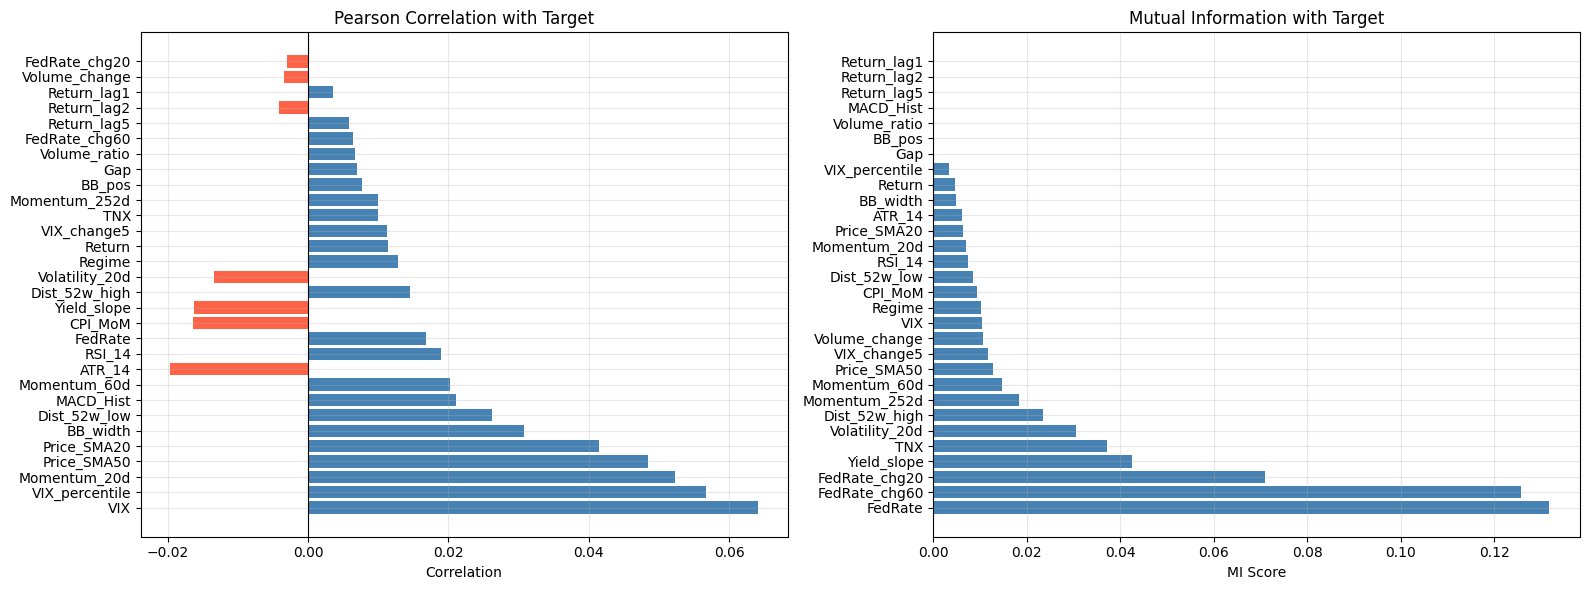

Top 5 by |Pearson|:
  VIX                   r=+0.0641
  VIX_percentile        r=+0.0568
  Momentum_20d          r=+0.0524
  Price_SMA50           r=+0.0484
  Price_SMA20           r=+0.0415

Top 5 by Mutual Information:
  FedRate               MI=0.1317
  FedRate_chg60         MI=0.1257
  FedRate_chg20         MI=0.0710
  Yield_slope           MI=0.0425
  TNX                   MI=0.0372


In [138]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import numpy as np

X_train = train_df_scaled[feature_cols].values
y_train = train_df[target_col].values

# Pearson 相关系数（对二值 target 等价于 point-biserial）
pearson = np.array([np.corrcoef(X_train[:, i], y_train)[0, 1] for i in range(len(feature_cols))])

# 互信息（捕捉非线性关系）
mi = mutual_info_classif(X_train, y_train, random_state=42)

# 排序展示
order = np.argsort(np.abs(pearson))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ["steelblue" if v >= 0 else "tomato" for v in pearson[order]]
axes[0].barh(np.array(feature_cols)[order], pearson[order], color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Pearson Correlation with Target")
axes[0].set_xlabel("Correlation")
axes[0].grid(True, alpha=0.3)

mi_order = np.argsort(mi)[::-1]
axes[1].barh(np.array(feature_cols)[mi_order], mi[mi_order], color="steelblue")
axes[1].set_title("Mutual Information with Target")
axes[1].set_xlabel("MI Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Top 5 by |Pearson|:")
for i in order[:5]:
    print(f"  {feature_cols[i]:20s}  r={pearson[i]:+.4f}")

print("\nTop 5 by Mutual Information:")
for i in mi_order[:5]:
    print(f"  {feature_cols[i]:20s}  MI={mi[i]:.4f}")

In [139]:
import torch.nn as nn



class ReturnPredictorModel(nn.Module):
    def __init__(self, input_size, macro_size, hidden_size=32, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )

        # 宏观特征单独走一个小 MLP，不经过 LSTM
        self.macro_mlp = nn.Sequential(
            nn.Linear(macro_size, 16),
            nn.ReLU(),
        )

        # LSTM 最后隐层 + 宏观 MLP 输出 → 分类
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size + 16, 1),
        )

    def forward(self, x, macro_last):
        # x         : (batch, seq_len, input_size)  全部特征序列
        # macro_last: (batch, macro_size)            最后时刻的宏观特征
        lstm_out, _ = self.lstm(x)
        last_hidden  = lstm_out[:, -1, :]           # (batch, hidden_size)
        macro_feat   = self.macro_mlp(macro_last)   # (batch, 16)
        combined     = torch.cat([last_hidden, macro_feat], dim=-1)
        return self.head(combined).squeeze(-1)

In [140]:
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device("cuda")
print("Using device:", device)

HIDDEN_SIZE = 32

model = ReturnPredictorModel(
    input_size=len(feature_cols),
    macro_size=len(MACRO_FEATURES),
    hidden_size=HIDDEN_SIZE,
    dropout=0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params}  Train samples: {len(train_dataset)}  Ratio: {len(train_dataset)/total_params:.2f}")

loss_fn = nn.BCEWithLogitsLoss()

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

Using device: cuda
Model params: 8369  Train samples: 2045  Ratio: 0.24


Running 10 restarts...
  Restart  1: best val = 0.693848  (41 epochs)
  Restart  2: best val = 0.693839  (42 epochs)
  Restart  3: best val = 0.697125  (42 epochs)
  Restart  4: best val = 0.692890  (41 epochs)
  Restart  5: best val = 0.698387  (42 epochs)
  Restart  6: best val = 0.690929  (43 epochs)
  Restart  7: best val = 0.694067  (43 epochs)
  Restart  8: best val = 0.692478  (43 epochs)
  Restart  9: best val = 0.692396  (42 epochs)
  Restart 10: best val = 0.696325  (41 epochs)

Best restart: #6  val loss = 0.690929


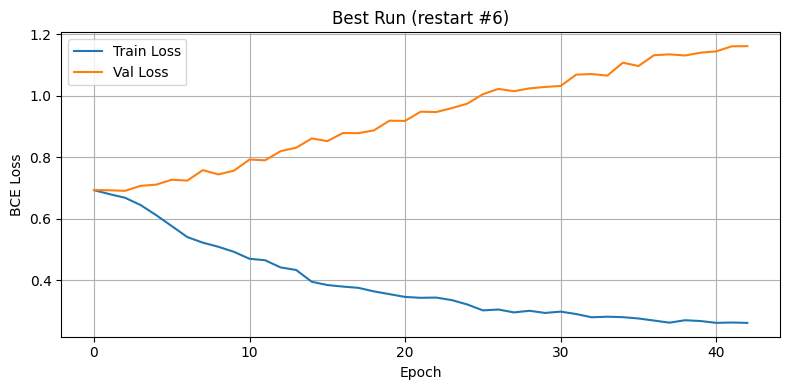

In [141]:
import matplotlib.pyplot as plt
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_one_run(seed):
    set_seed(seed)

    m = ReturnPredictorModel(
        input_size=len(feature_cols),
        macro_size=len(MACRO_FEATURES),
        hidden_size=HIDDEN_SIZE,
        dropout=0.3,
    ).to(device)

    opt = optim.Adam(m.parameters(), lr=0.001)
    sch = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=10, min_lr=1e-5
    )

    best_val   = float("inf")
    best_state = None
    no_improve = 0
    t_losses, v_losses = [], []

    for epoch in range(300):
        m.train()
        running = 0.0
        for x_seq, macro_last, y in train_loader:
            x_seq, macro_last, y = x_seq.to(device), macro_last.to(device), y.to(device)
            loss = loss_fn(m(x_seq, macro_last), y)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            running += loss.item()
        avg_train = running / len(train_loader)
        t_losses.append(avg_train)

        m.eval()
        running = 0.0
        with torch.no_grad():
            for x_seq, macro_last, y in val_loader:
                x_seq, macro_last, y = x_seq.to(device), macro_last.to(device), y.to(device)
                running += loss_fn(m(x_seq, macro_last), y).item()
        avg_val = running / len(val_loader)
        v_losses.append(avg_val)
        sch.step(avg_val)

        if avg_val < best_val:
            best_val   = avg_val
            best_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= 40:
            break

    return best_val, best_state, t_losses, v_losses


N_RESTARTS = 10
best_overall_val   = float("inf")
best_overall_state = None
best_run_idx = -1
all_t_losses, all_v_losses = [], []

print(f"Running {N_RESTARTS} restarts...")
for i in range(N_RESTARTS):
    val_loss, state, tl, vl = train_one_run(seed=i * 17)
    all_t_losses.append(tl); all_v_losses.append(vl)
    print(f"  Restart {i+1:2d}: best val = {val_loss:.6f}  ({len(tl)} epochs)")
    if val_loss < best_overall_val:
        best_overall_val   = val_loss
        best_overall_state = state
        best_run_idx = i

print(f"\nBest restart: #{best_run_idx+1}  val loss = {best_overall_val:.6f}")
model.load_state_dict(best_overall_state)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(all_t_losses[best_run_idx], label="Train Loss")
ax.plot(all_v_losses[best_run_idx], label="Val Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title(f"Best Run (restart #{best_run_idx+1})")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

In [142]:
from sklearn.metrics import f1_score, roc_auc_score

model.eval()

# 测试集推理
all_preds, all_targets = [], []
with torch.no_grad():
    for x_seq, macro_last, y in test_loader:
        x_seq, macro_last = x_seq.to(device), macro_last.to(device)
        prob = torch.sigmoid(model(x_seq, macro_last))
        all_preds.append(prob.cpu().numpy())
        all_targets.append(y.numpy())

preds   = np.concatenate(all_preds)
targets = np.concatenate(all_targets)
print(f"Prob range: [{preds.min():.3f}, {preds.max():.3f}]  std={preds.std():.3f}")

Prob range: [0.381, 0.678]  std=0.059


In [143]:
from sklearn.metrics import precision_score, recall_score

true_dir  = (targets > 0.5).astype(int)
pred_dir  = (preds > 0.5).astype(int)

corr      = np.corrcoef(preds, targets)[0, 1]
baseline  = np.mean(true_dir)
acc       = np.mean(pred_dir == true_dir)
f1        = f1_score(true_dir, pred_dir)
auc       = roc_auc_score(true_dir, preds)

print("===== TEST RESULTS =====")
print(f"AUC-ROC  : {auc:.4f}")
print(f"Corr     : {corr:.4f}")
print(f"Baseline : {baseline:.4f}")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")

# 高置信度子集
CONF = 0.6
high_conf = (preds > CONF) | (preds < (1 - CONF))
if high_conf.sum() > 0:
    hc_true = true_dir[high_conf]
    hc_pred = pred_dir[high_conf]
    print(f"\n===== HIGH-CONFIDENCE SUBSET (>{CONF} or <{1-CONF}) =====")
    print(f"Coverage : {high_conf.mean():.1%}  ({high_conf.sum()} samples)")
    print(f"Accuracy : {np.mean(hc_pred == hc_true):.4f}")
    print(f"AUC-ROC  : {roc_auc_score(hc_true, preds[high_conf]):.4f}")

===== TEST RESULTS =====
AUC-ROC  : 0.6672
Corr     : 0.2514
Baseline : 0.5758
Accuracy : 0.6291
F1 Score : 0.7069

===== HIGH-CONFIDENCE SUBSET (>0.6 or <0.4) =====
Coverage : 12.2%  (101 samples)
Accuracy : 0.7525
AUC-ROC  : 0.7163


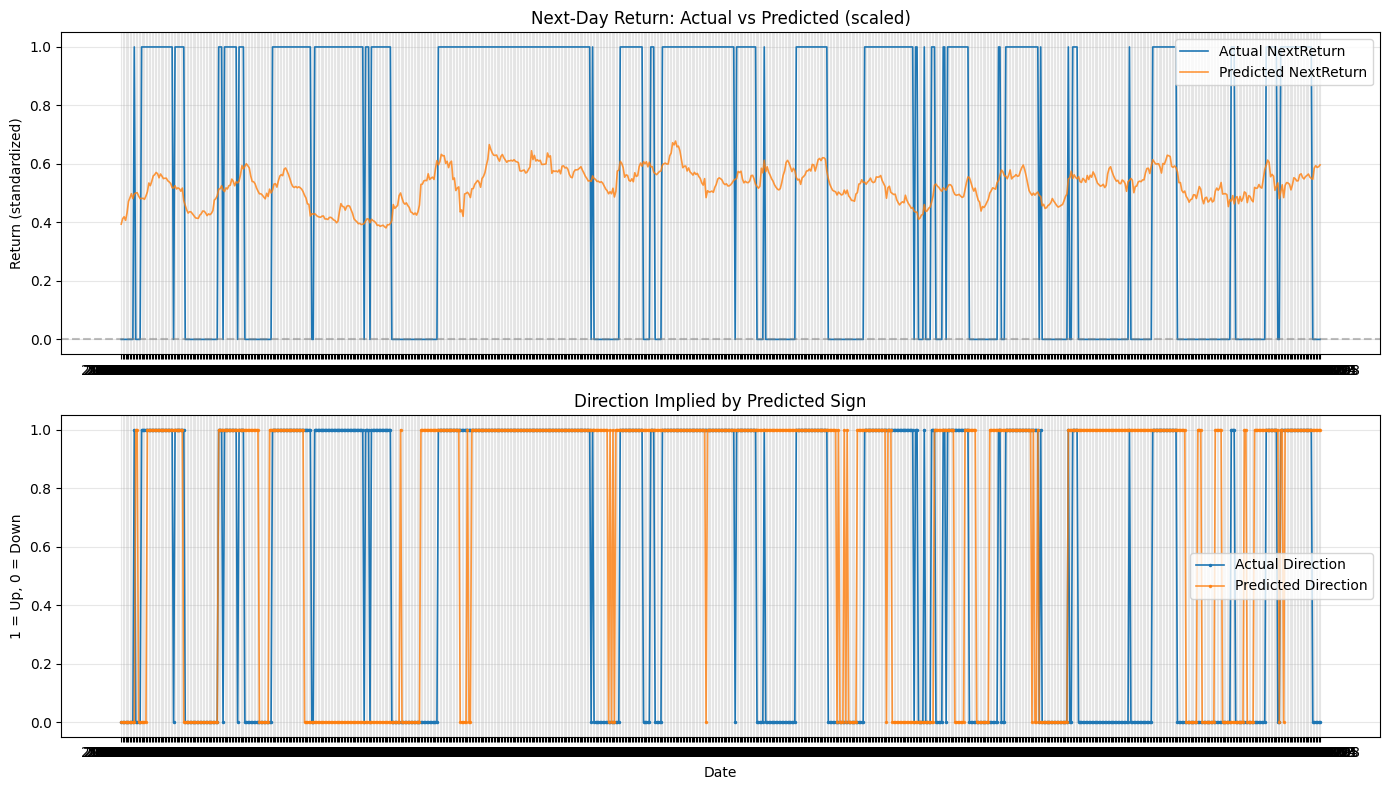

In [144]:
test_dates = test_df["Date"].values[WINDOW_SIZE:WINDOW_SIZE + len(preds)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(test_dates, targets, label="Actual NextReturn", linewidth=1.2)
axes[0].plot(test_dates, preds,   label="Predicted NextReturn", linewidth=1.2, alpha=0.8)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title("Next-Day Return: Actual vs Predicted (scaled)")
axes[0].set_ylabel("Return (standardized)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_dates, (targets > 0.5).astype(int), label="Actual Direction", linewidth=1.2, marker='.', markersize=3)
axes[1].plot(test_dates, (preds > 0.5).astype(int),   label="Predicted Direction", linewidth=1.2, alpha=0.8, marker='.', markersize=3)
axes[1].set_title("Direction Implied by Predicted Sign")
axes[1].set_ylabel("1 = Up, 0 = Down")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

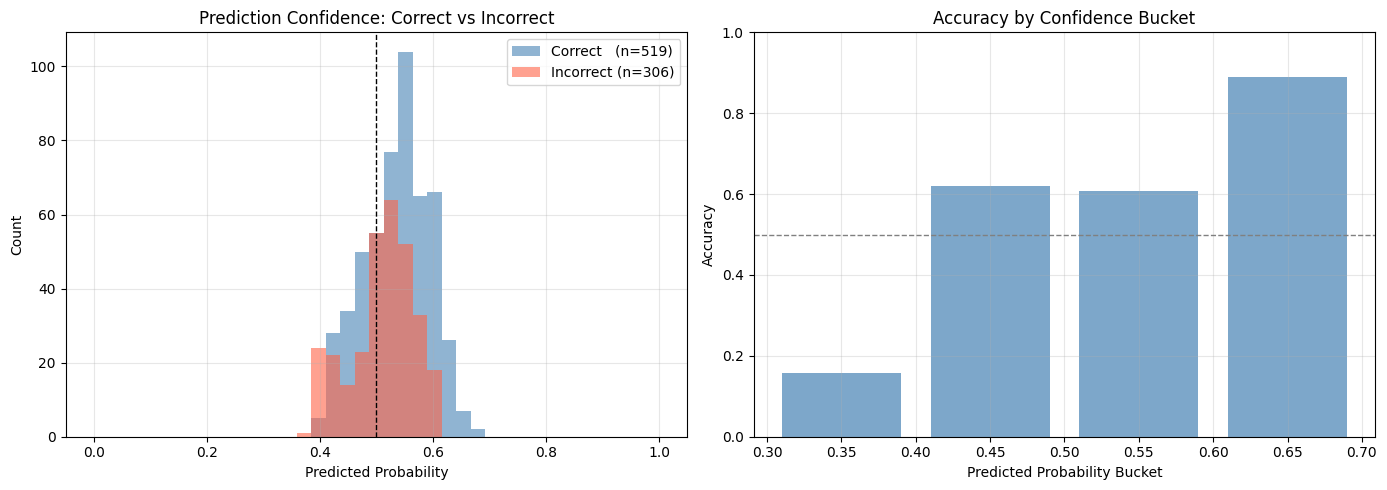


Accuracy by confidence bucket:
  prob ~0.35  n=  19  acc=0.158
  prob ~0.45  n= 237  acc=0.620
  prob ~0.55  n= 487  acc=0.608
  prob ~0.65  n=  82  acc=0.890


In [145]:
pred_dir     = (preds > 0.5).astype(int)
correct_mask = (pred_dir == true_dir)

pred_probs_correct   = preds[correct_mask]
pred_probs_incorrect = preds[~correct_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, 1, 40)
axes[0].hist(pred_probs_correct,   bins=bins, alpha=0.6, label=f"Correct   (n={correct_mask.sum()})",    color="steelblue")
axes[0].hist(pred_probs_incorrect, bins=bins, alpha=0.6, label=f"Incorrect (n={(~correct_mask).sum()})", color="tomato")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Count")
axes[0].set_title("Prediction Confidence: Correct vs Incorrect")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

bucket_edges = np.linspace(0, 1, 11)
bucket_acc = []
bucket_centers = []
for i in range(len(bucket_edges) - 1):
    lo, hi = bucket_edges[i], bucket_edges[i+1]
    mask = (preds >= lo) & (preds < hi)
    if mask.sum() == 0:
        continue
    acc = np.mean(pred_dir[mask] == true_dir[mask])
    bucket_acc.append(acc)
    bucket_centers.append((lo + hi) / 2)

axes[1].bar(bucket_centers, bucket_acc, width=0.08, color="steelblue", alpha=0.7)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Probability Bucket")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy by Confidence Bucket")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAccuracy by confidence bucket:")
for c, a in zip(bucket_centers, bucket_acc):
    n = ((preds >= c - 0.05) & (preds < c + 0.05)).sum()
    print(f"  prob ~{c:.2f}  n={n:4d}  acc={a:.3f}")